# Specimen 01 — Iris Classification

Goal: build the full pipeline correctly end-to-end on easy terrain. Follow the field journal's Phase 1 guide for what each step should cover.

In [ ]:
import pandas as pd #Pandas is a fast, powerful, flexible and easy to use open source data analysis and manipulation tool, built on top of the Python programming language.
import numpy as np #Numpy is a library for the Python programming language, adding support for large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays.
import matplotlib.pyplot as plt #Matplotlib is a comprehensive library for creating static, animated, and interactive visualizations in Python.
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score #Scikit-learn is a free software machine learning library for the Python programming language. It features various classification, regression and clustering algorithms including support vector machines, random forests, gradient boosting, k-means and DBSCAN, and is designed to interoperate with the Python numerical and scientific libraries NumPy and SciPy.


## 1. Load & inspect

Load `sklearn.datasets.load_iris()`. Check shape, feature names, class balance.

In [1]:
#Sklearn datasets brings in popular datasets for machine learning
from sklearn.datasets import load_iris
# Import pandas gives us data manipulation and analysis tools
# "as pd" is a common convention for pandas
import pandas as pd
# Load the iris dataset
iris = load_iris()
# Create a DataFrame from the iris data
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
# Add the target column to the DataFrame, mapping numeric values to their corresponding species names
df['species'] = iris.target_names[iris.target]
# Display the DataFrame
print("Shape: ", df.shape)
# Display the feature names
print("Feature names: ", iris.feature_names)
# Display the first few rows of the DataFrame
print("Class balance: ")
# Display the class distribution
print(df['species'].value_counts())
# Display the first few rows of the DataFrame
df.head()

Shape:  (150, 5)
Feature names:  ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Class balance: 
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 2. Visualize

Pairplot the four features colored by species. Which pair separates classes best?

Matplotlib is building the font cache; this may take a moment.


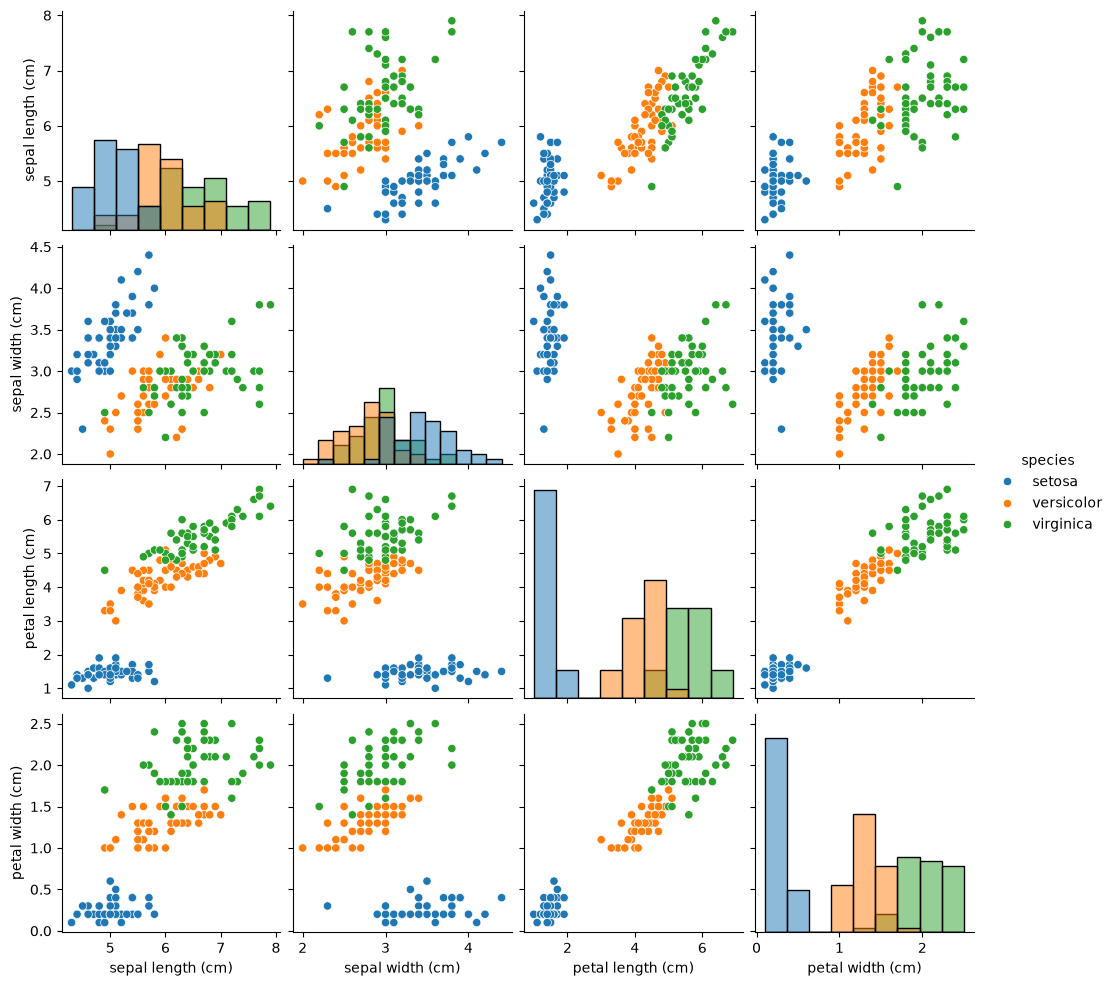

In [2]:
#Seaborn is a data visualization library based on matplotlib that provides a high-level interface for drawing attractive and informative 
#statistical graphics
import seaborn as sns
#Matplotlib is a plotting library for the Python programming language and its numerical mathematics extension NumPy. 
# It provides an object-oriented API for embedding plots into applications using general-purpose GUI toolkits like Tkinter, wxPython, Qt, or GTK.
import matplotlib.pyplot as plt
# Create a pairplot of the DataFrame, coloring by species and using histograms for the
sns.pairplot(df, hue='species', diag_kind='hist')
# Show the plot
plt.show()

## 3. Stratified split

`train_test_split(..., stratify=y)`.

In [ ]:
#Model_Selection is a process of selecting the best model from a set of candidate models based on their performance on a given dataset. 
# It involves evaluating the models using various metrics and selecting the one that performs the best.
from sklearn.model_selection import train_test_split

X = df[iris.feature_names]  # Features
Y = df['species']  # Target variable

# Split the dataset into training and testing sets, with 20% of the data reserved for testing
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Display the shape of the training and testing sets
print("Train Class balance: \n", Y_train.value_counts())
# Display the class distribution in the test set
print("Test Class balance: \n", Y_test.value_counts())

Train Class balance: 
 species
versicolor    41
setosa        40
virginica     39
Name: count, dtype: int64
Test Class balance: 
 species
virginica     11
setosa        10
versicolor     9
Name: count, dtype: int64


## 4. Baseline model

Fit a plain `LogisticRegression`. This is your floor.

In [ ]:
#Linear_models is a module in scikit-learn that provides various linear models for regression and classification tasks.
#LogisticRegression is a linear model for classification that estimates the probability of a binary response based on one or more predictor variables.
from sklearn.linear_model import LogisticRegression
#Sklearn metrics module provides functions to evaluate the performance of machine learning models.
from sklearn.metrics import accuracy_score, classification_report

# Create a baseline logistic regression model with a maximum of 1000 iterations
baseline = LogisticRegression(max_iter=1000)
# Fit the baseline model to the training data
baseline.fit(X_train, Y_train)

# Make predictions on the test set using the baseline model
y_pred = baseline.predict(X_test)

# Calculate and print the accuracy score of the baseline model on the test set
print("Accuracy: ", accuracy_score(Y_test, y_pred))
# Calculate and print the classification report, which includes precision, recall, f1-score, and support for each class
print("\n", classification_report(Y_test, y_pred))

Accuracy:  1.0

               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## 5. Cross-validate properly

`StratifiedKFold` + `cross_val_score`. Compare mean/std across folds.

In [ ]:
#StratifiedKFold is a cross-validator that provides train/test indices to split data into train/test sets 
#while preserving the percentage of samples for each class.
#Cross_val_score is a function that evaluates a score by cross-validation, splitting the dataset into k folds and returning the scores for each fold.
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Create a StratifiedKFold cross-validator with 5 splits, shuffling the data and setting a random state for reproducibility
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# Perform cross-validation using the baseline model, features (X), target variable (Y), and the StratifiedKFold cross-validator
cv_scores = cross_val_score(baseline, X, Y, cv=skf)

# Print the cross-validation scores, mean score, and standard deviation of the scores
print("CV Scores: ", cv_scores)
#Print the mean of the cross-validation scores
print("Mean CV Score: ", cv_scores.mean())
#Print the standard deviation of the cross-validation scores
print("Standard Deviation of CV Scores: ", cv_scores.std())

CV Scores:  [1.         0.96666667 0.93333333 1.         0.93333333]
Mean CV Score:  0.9666666666666668
Standard Deviation of CV Scores:  0.029814239699997188


## 6. Compare 3+ model families

Logistic regression, KNN, decision tree — same CV setup.

In [6]:
#Sklearn Neighbors module provides functionality for implementing the k-nearest neighbors algorithm, which is a simple, 
# instance-based learning method used for classification and regression tasks.
#KNeighborsClassifier is a class that implements the k-nearest neighbors algorithm for classification tasks, 
# allowing you to fit a model to your data and make predictions based on the majority class of the nearest neighbors.
from sklearn.neighbors import KNeighborsClassifier
#DecisionTreeClassifier is a class that implements the decision tree algorithm for classification tasks,
# allowing you to fit a model to your data and make predictions based on the learned decision rules
from sklearn.tree import DecisionTreeClassifier

models = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "KNeighborsClassifier": KNeighborsClassifier(),
    "DecisionTreeClassifier": DecisionTreeClassifier()
}

# Perform cross-validation for each model and print the mean and standard deviation of the scores
for name, model in models.items():
    #Create a StratifiedKFold cross-validator with 5 splits, shuffling the data and setting a random state for reproducibility
    scores = cross_val_score(model, X, Y, cv=skf)
    #Print the mean and standard deviation of the cross-validation scores for each model
    print(f"{name}: mean={scores.mean():.4f}, std={scores.std():.4f}")

LogisticRegression: mean=0.9667, std=0.0298
KNeighborsClassifier: mean=0.9667, std=0.0298
DecisionTreeClassifier: mean=0.9533, std=0.0340


## 7. Look past accuracy

`confusion_matrix` and `classification_report` for your best model.

In [ ]:
#Metrics module in scikit-learn provides functions to evaluate the performance of machine learning models.
#Confusion matrix is a table that is often used to describe the performance of a 
# classification model on a set of test data for which the true values are known.
# Classification report is a text summary of the precision, recall, f1-score, and support for each class in a classification model.
from sklearn.metrics import confusion_matrix, classification_report

best_model = KNeighborsClassifier() #KNeighborsClassifier is a class that implements the k-nearest neighbors algorithm for classification tasks
best_model.fit(X_train, Y_train) #Fit the best model to the training data
y_pred = best_model.predict(X_test) #Make predictions on the test set using the best model

print(confusion_matrix(Y_test, y_pred)) #Print the confusion matrix for the test set predictions
print(classification_report(Y_test, y_pred)) #Print the classification report for the test set predictions

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## 8. Final test evaluation

Touch the held-out test set exactly once. Record the number.

In [12]:
y_pred_final = best_model.predict(X_test) #Make predictions on the entire dataset using the best model
print("Final Predictions: ", y_pred_final) #Print the final predictions for the entire dataset
print("\n", confusion_matrix(Y_test, y_pred_final)) #Print the confusion matrix for the entire dataset predictions
print("\n", classification_report(Y_test, y_pred_final)) #Print the classification report for the entire dataset predictions

Final Predictions:  ['versicolor' 'setosa' 'virginica' 'versicolor' 'versicolor' 'setosa'
 'versicolor' 'virginica' 'versicolor' 'versicolor' 'virginica' 'setosa'
 'setosa' 'setosa' 'setosa' 'versicolor' 'virginica' 'versicolor'
 'versicolor' 'virginica' 'setosa' 'virginica' 'setosa' 'virginica'
 'virginica' 'virginica' 'virginica' 'virginica' 'setosa' 'setosa']

 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

